This notebook is part of the $\omega radlib$ documentation: https://docs.wradlib.org.

Copyright (c) $\omega radlib$ developers.
Distributed under the MIT License. See LICENSE.txt for more info.

# Production of a maximum reflectivity composite

In [1]:
import os
import numpy as np
import wradlib
import xarray
import xradar
import matplotlib.pyplot as plt

Read volume reflectivity measurements from the three belgian radars

In [2]:
from wradlib_data import DATASETS

filenames = ["bejab.pvol.hdf", "bewid.pvol.hdf", "behel.pvol.hdf"]
paths = [DATASETS.fetch(f"hdf5/{f}") for f in filenames]
volumes = [xradar.io.backends.odim.open_odim_datatree(p) for p in paths]

Define a raster dataset with a window including the 3 radars, a pixel size of 1km and the standard European projection.

In [3]:
crs = 3035
bounds = [3614000, 2783000, 4200000, 3338000]
resolution = 1000
raster1 = wradlib.georef.create_raster_xarray(crs, bounds, resolution)
print(raster1)

<xarray.Dataset> Size: 9kB
Dimensions:      (x: 586, y: 555)
Coordinates:
  * x            (x) int64 5kB 3614500 3615500 3616500 ... 4198500 4199500
  * y            (y) int64 4kB 3337500 3336500 3335500 ... 2784500 2783500
    spatial_ref  int64 8B 0
Data variables:
    *empty*
<xarray.Dataset> Size: 9kB
Dimensions:      (x: 586, y: 555)
Coordinates:
  * x            (x) int64 5kB 3614500 3615500 3616500 ... 4198500 4199500
  * y            (y) int64 4kB 3337500 3336500 3335500 ... 2784500 2783500
    spatial_ref  int64 8B 0
Data variables:
    *empty*
<xarray.Dataset> Size: 9kB
Dimensions:      (x: 586, y: 555)
Coordinates:
  * x            (x) int64 5kB 3614500 3615500 3616500 ... 4198500 4199500
  * y            (y) int64 4kB 3337500 3336500 3335500 ... 2784500 2783500
    spatial_ref  int64 8B 0
Data variables:
    *empty*


Define a geographic raster dataset with a window including the 3 radars, and an approximate pixel size of 1km. 

In [4]:
crs = 3035
bounds = [0, 48, 9, 53]
resolution = 1000
raster2 = wradlib.georef.create_raster_geographic(bounds, resolution, resolution_in_meters=True)
print(raster2)

<xarray.Dataset> Size: 10kB
Dimensions:      (x: 648, y: 600)
Coordinates:
  * x            (x) int64 5kB 25 75 125 175 225 ... 32225 32275 32325 32375
  * y            (y) int64 5kB 190785 190755 190725 ... 172875 172845 172815
    spatial_ref  int64 8B 0
Data variables:
    *empty*
<xarray.Dataset> Size: 10kB
Dimensions:      (x: 648, y: 600)
Coordinates:
  * x            (x) int64 5kB 25 75 125 175 225 ... 32225 32275 32325 32375
  * y            (y) int64 5kB 190785 190755 190725 ... 172875 172845 172815
    spatial_ref  int64 8B 0
Data variables:
    *empty*
<xarray.Dataset> Size: 10kB
Dimensions:      (x: 648, y: 600)
Coordinates:
  * x            (x) int64 5kB 25 75 125 175 225 ... 32225 32275 32325 32375
  * y            (y) int64 5kB 190785 190755 190725 ... 172875 172845 172815
    spatial_ref  int64 8B 0
Data variables:
    *empty*


Combine lowest radar sweep into a raster image for each radar

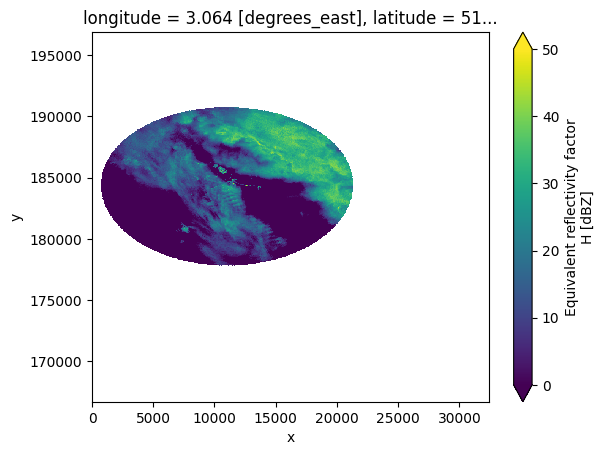

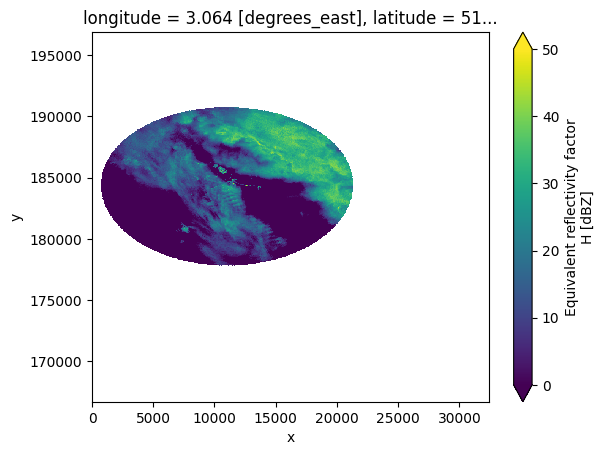

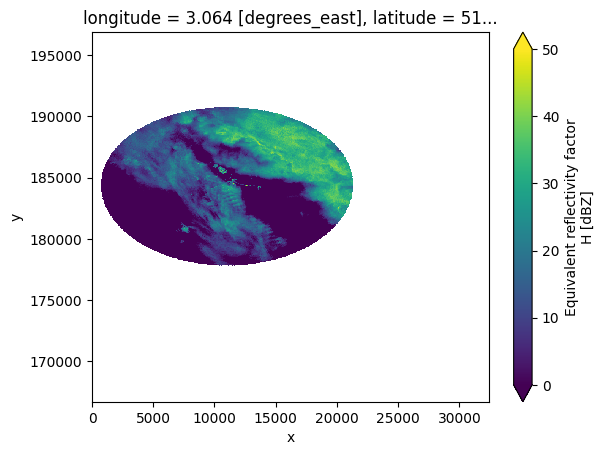

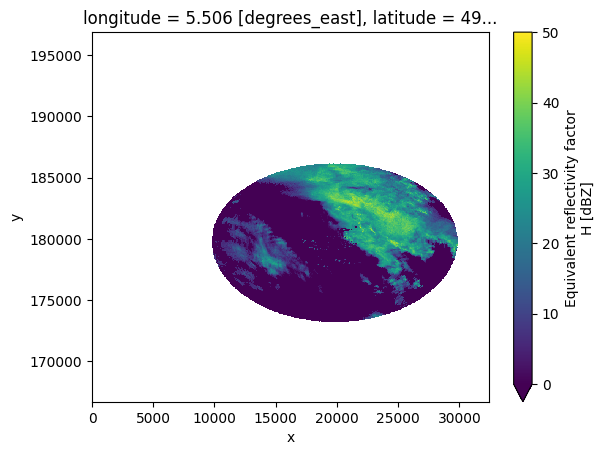

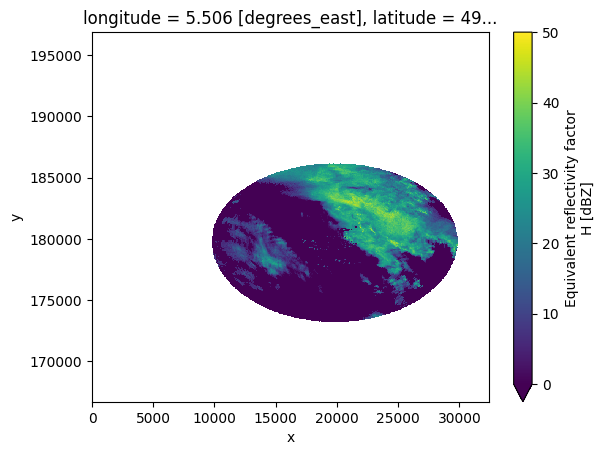

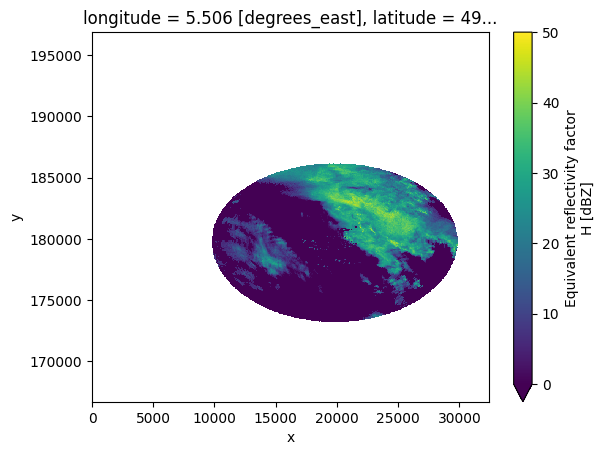

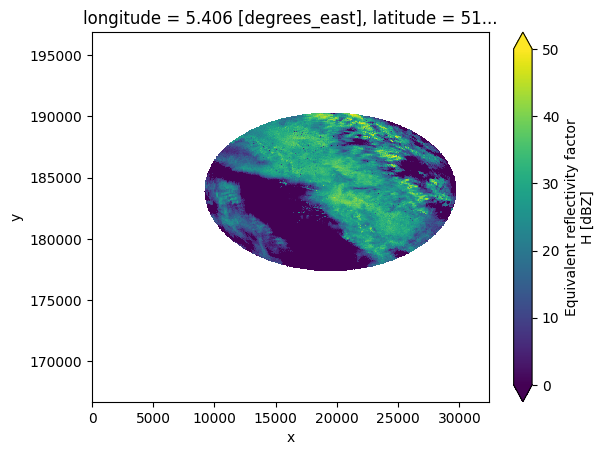

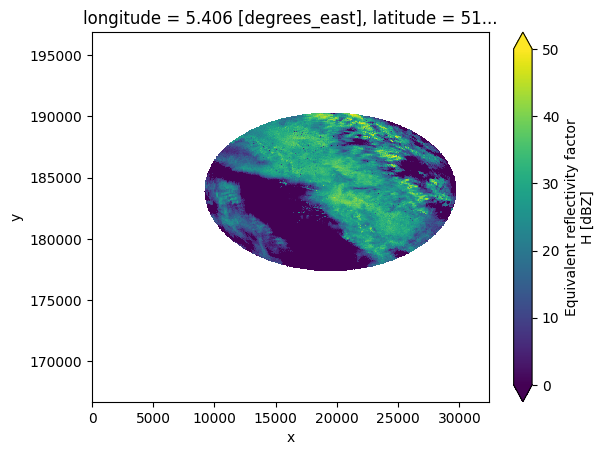

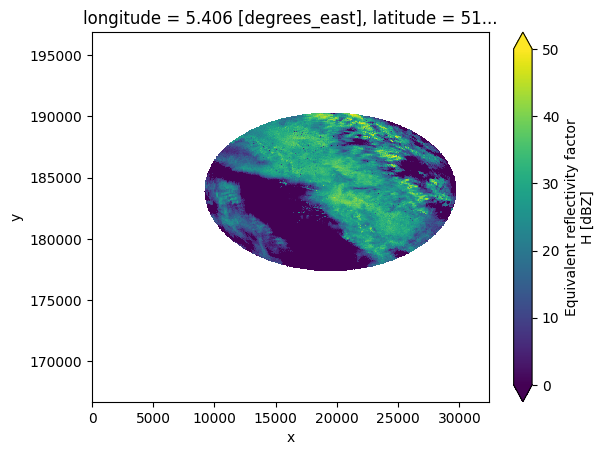

In [5]:
raster = raster2
metadata = xradar.model.required_sweep_metadata_vars
rasters = []
for volume in volumes:
    sweep = volume["sweep_0"].to_dataset()
    sweep = sweep[["DBZH"] + list(metadata)]
    sweep = sweep.sel(range=slice(0, 200e3))
    raster_sweep = wradlib.comp.sweep_to_raster(sweep, raster)
    rasters.append(raster_sweep)

for raster in rasters:        
    raster["DBZH"].plot(vmin=0, vmax=50)
    plt.axis("equal")
    plt.show()

Take the maximum value from the 3 rasters

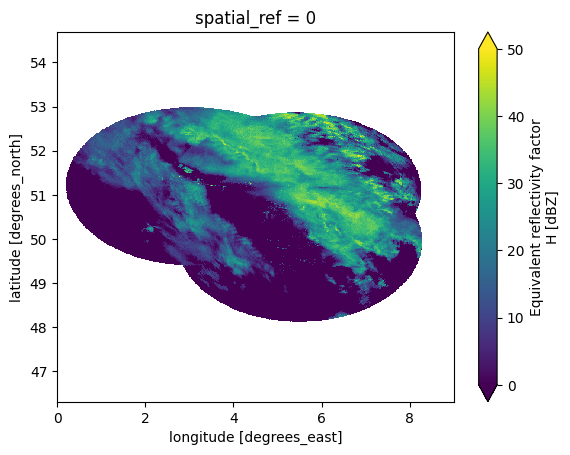

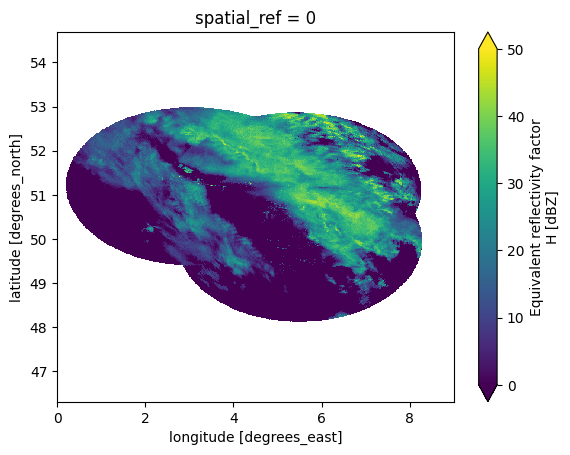

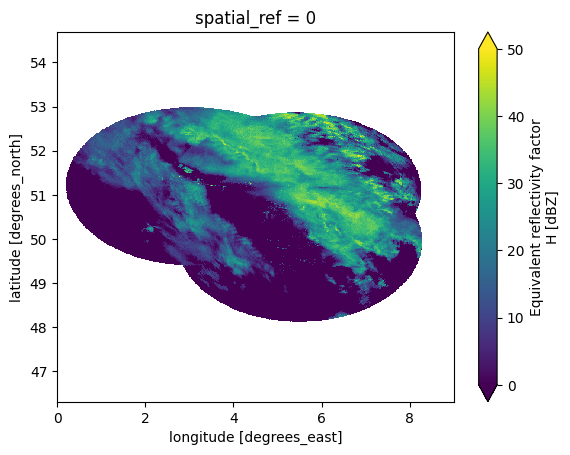

In [6]:
rasters_concat = xarray.concat(rasters, dim="sweep")
comp = rasters_concat.max(dim="sweep", keep_attrs=True)
comp["DBZH"].attrs["grid_mapping"] = "spatial_ref"
with open("comp.nc", "wb") as f:
    comp.to_netcdf(f)
ds = xarray.open_dataset('comp.nc')
ds = ds.rio.reproject("EPSG:4326")
ds["DBZH"].plot(vmin=0, vmax=50)
plt.axis("equal")
plt.show()